In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

from rich import print

import ewatercycle
import ewatercycle.forcing

In [2]:
forcing_path_ERA5 = Path.home() / "BEP-beau/BEP/code" / "CatchmentArea" / "ERA5_1" / "own_shapefile_1"
load_location = forcing_path_ERA5 / "work" / "diagnostic" / "script"  
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)

In [3]:
print(ERA5_forcing)

LumpedMakkinkForcing(
    start_time='1975-01-01T00:00:00Z',
    end_time='2020-12-31T00:00:00Z',
    directory=PosixPath('/home/beau/BEP-beau/BEP/code/CatchmentArea/ERA5_1/own_shapefile_1/work/diagnostic/script')
,
    shape=PosixPath('/home/beau/BEP-beau/BEP/code/CatchmentArea/ERA5_1/own_shapefile_1/work/diagnostic/script/Catch
mentArea_4326.shp'),
    filenames={
        'pr': 'OBS6_ERA5_reanaly_1_day_pr_1975-2020.nc',
        'tas': 'OBS6_ERA5_reanaly_1_day_tas_1975-2020.nc',
        'rsds': 'OBS6_ERA5_reanaly_1_day_rsds_1975-2020.nc',
        'evspsblpot': 'Derived_Makkink_evspsblpot.nc'
    }
)

In [4]:
pr = xr.open_dataset(ERA5_forcing['pr'])
tas = xr.open_dataset(ERA5_forcing['tas'])
rsds = xr.open_dataset(ERA5_forcing['rsds'])
evspsblpot = xr.open_dataset(ERA5_forcing['evspsblpot'])

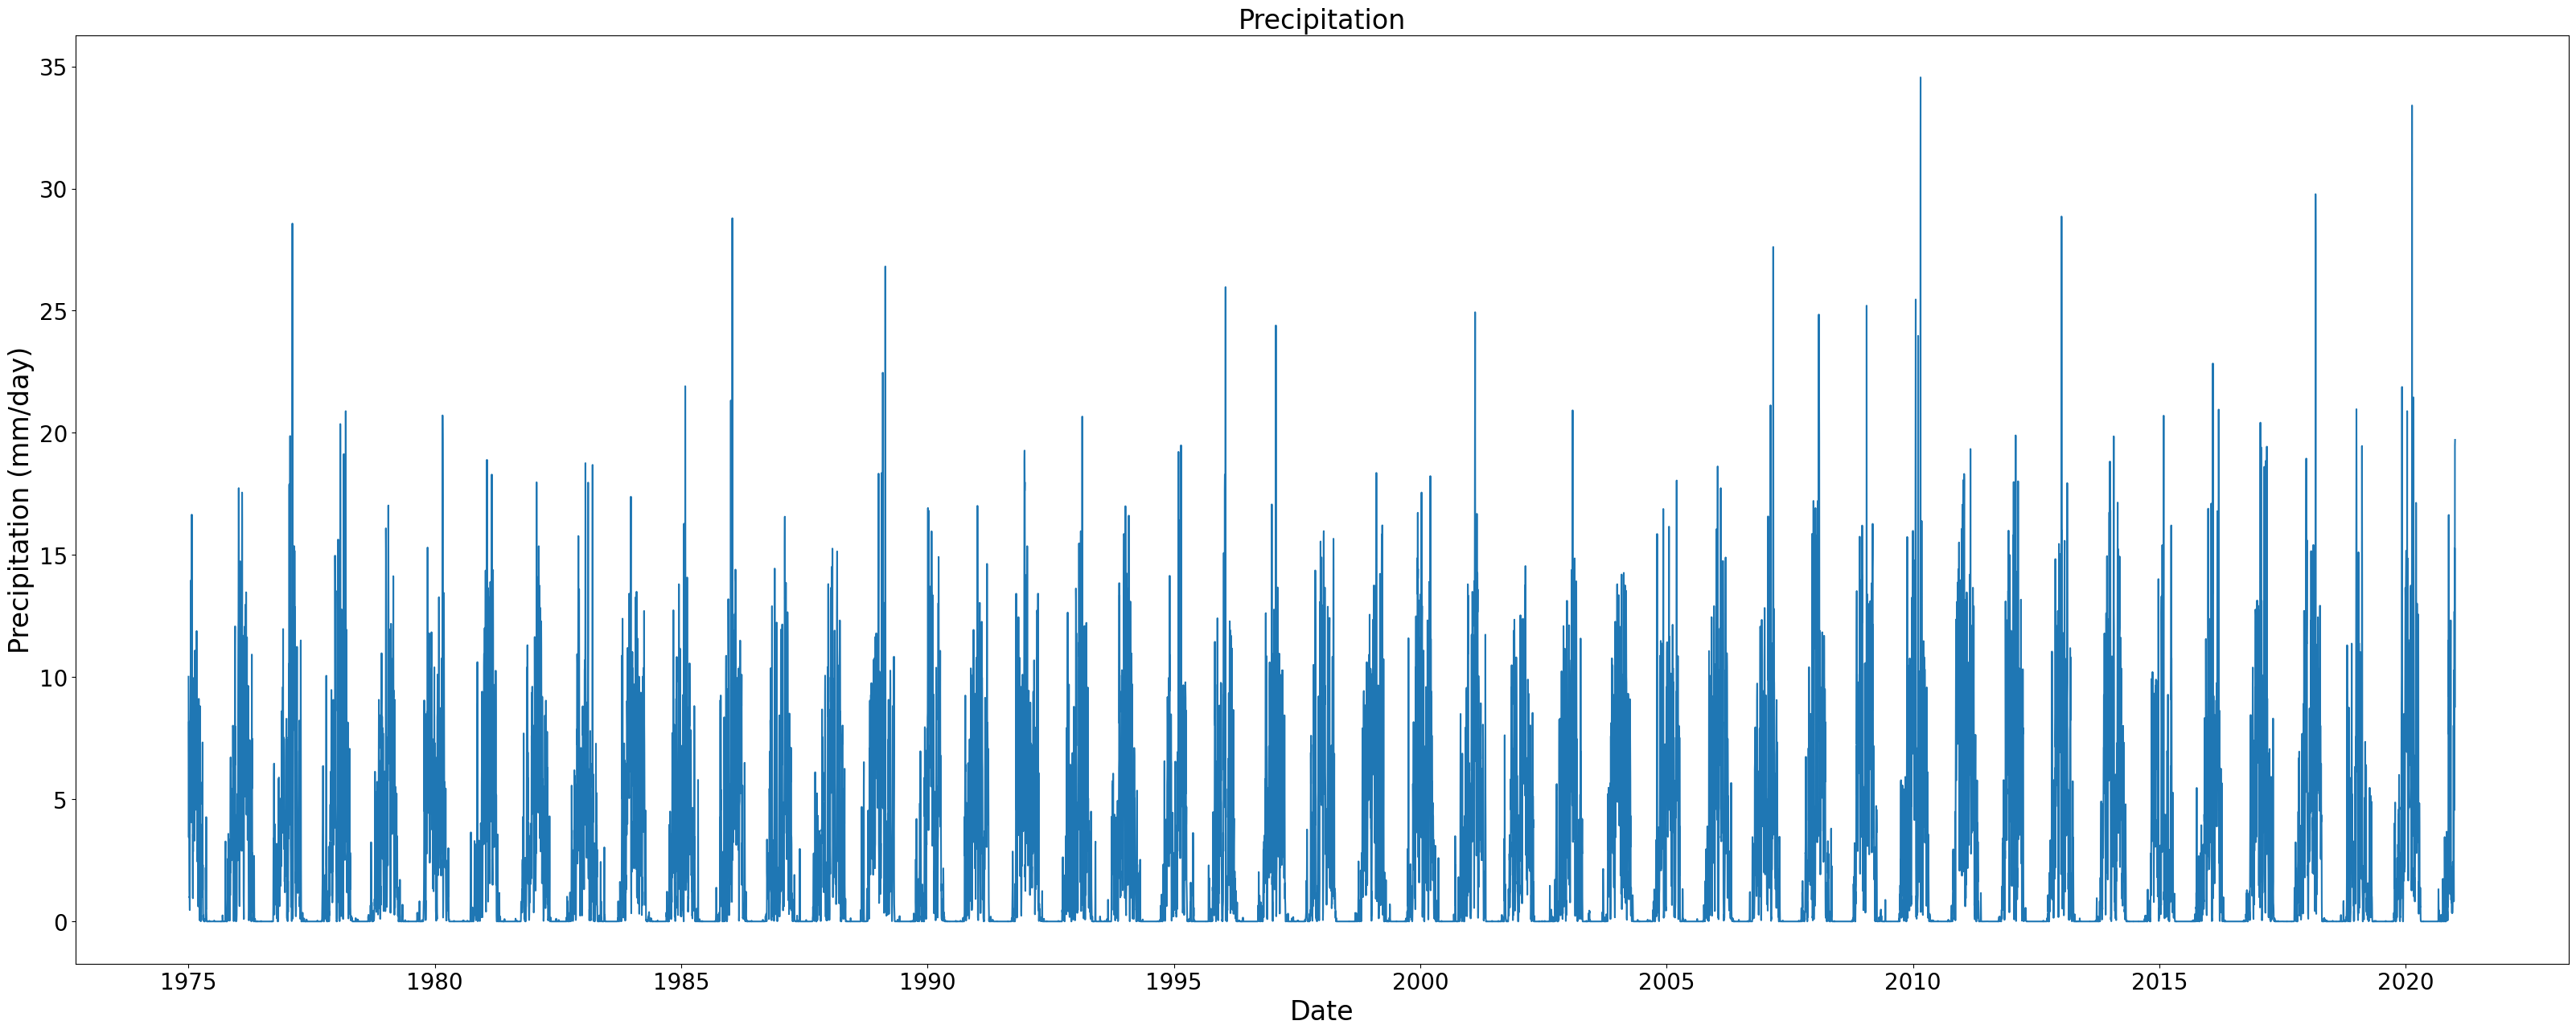

In [12]:
fig, ax = plt.subplots(figsize=(40, 15))
pr_mm_day['pr'] = pr['pr'] * 86400
pr_mm_day['pr'].plot(ax=ax)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Precipitation (mm/day)", fontsize=24)
plt.title("Precipitation", fontsize=24);

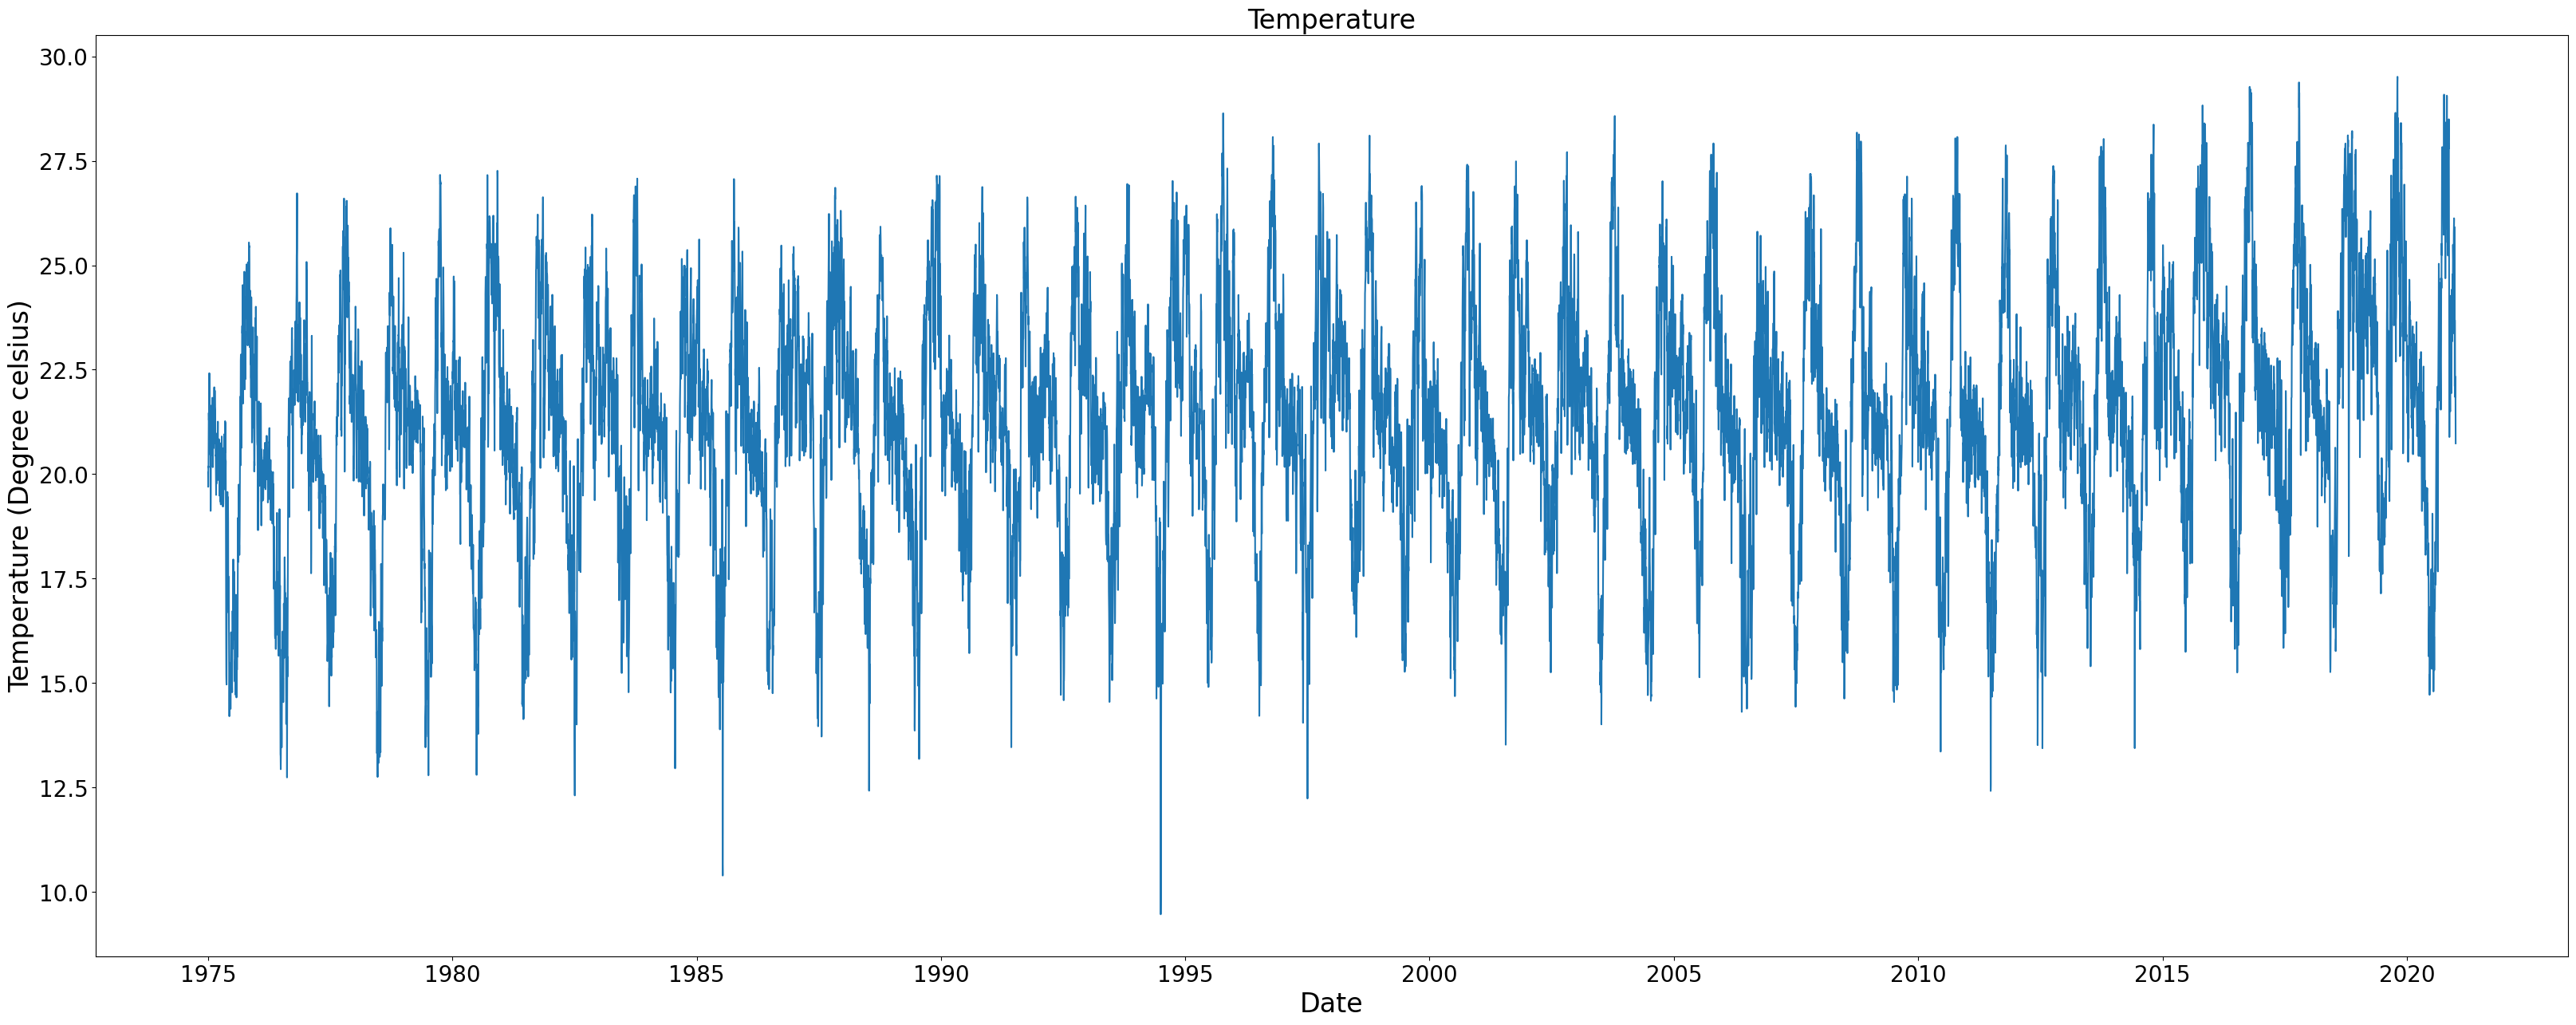

In [6]:
tas['tas'] = tas['tas'] - 273.15

fig, ax = plt.subplots(figsize=(40, 15))
tas['tas'].plot(ax=ax)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Temperature (Degree celsius)", fontsize=24)
plt.title("Temperature", fontsize=24);

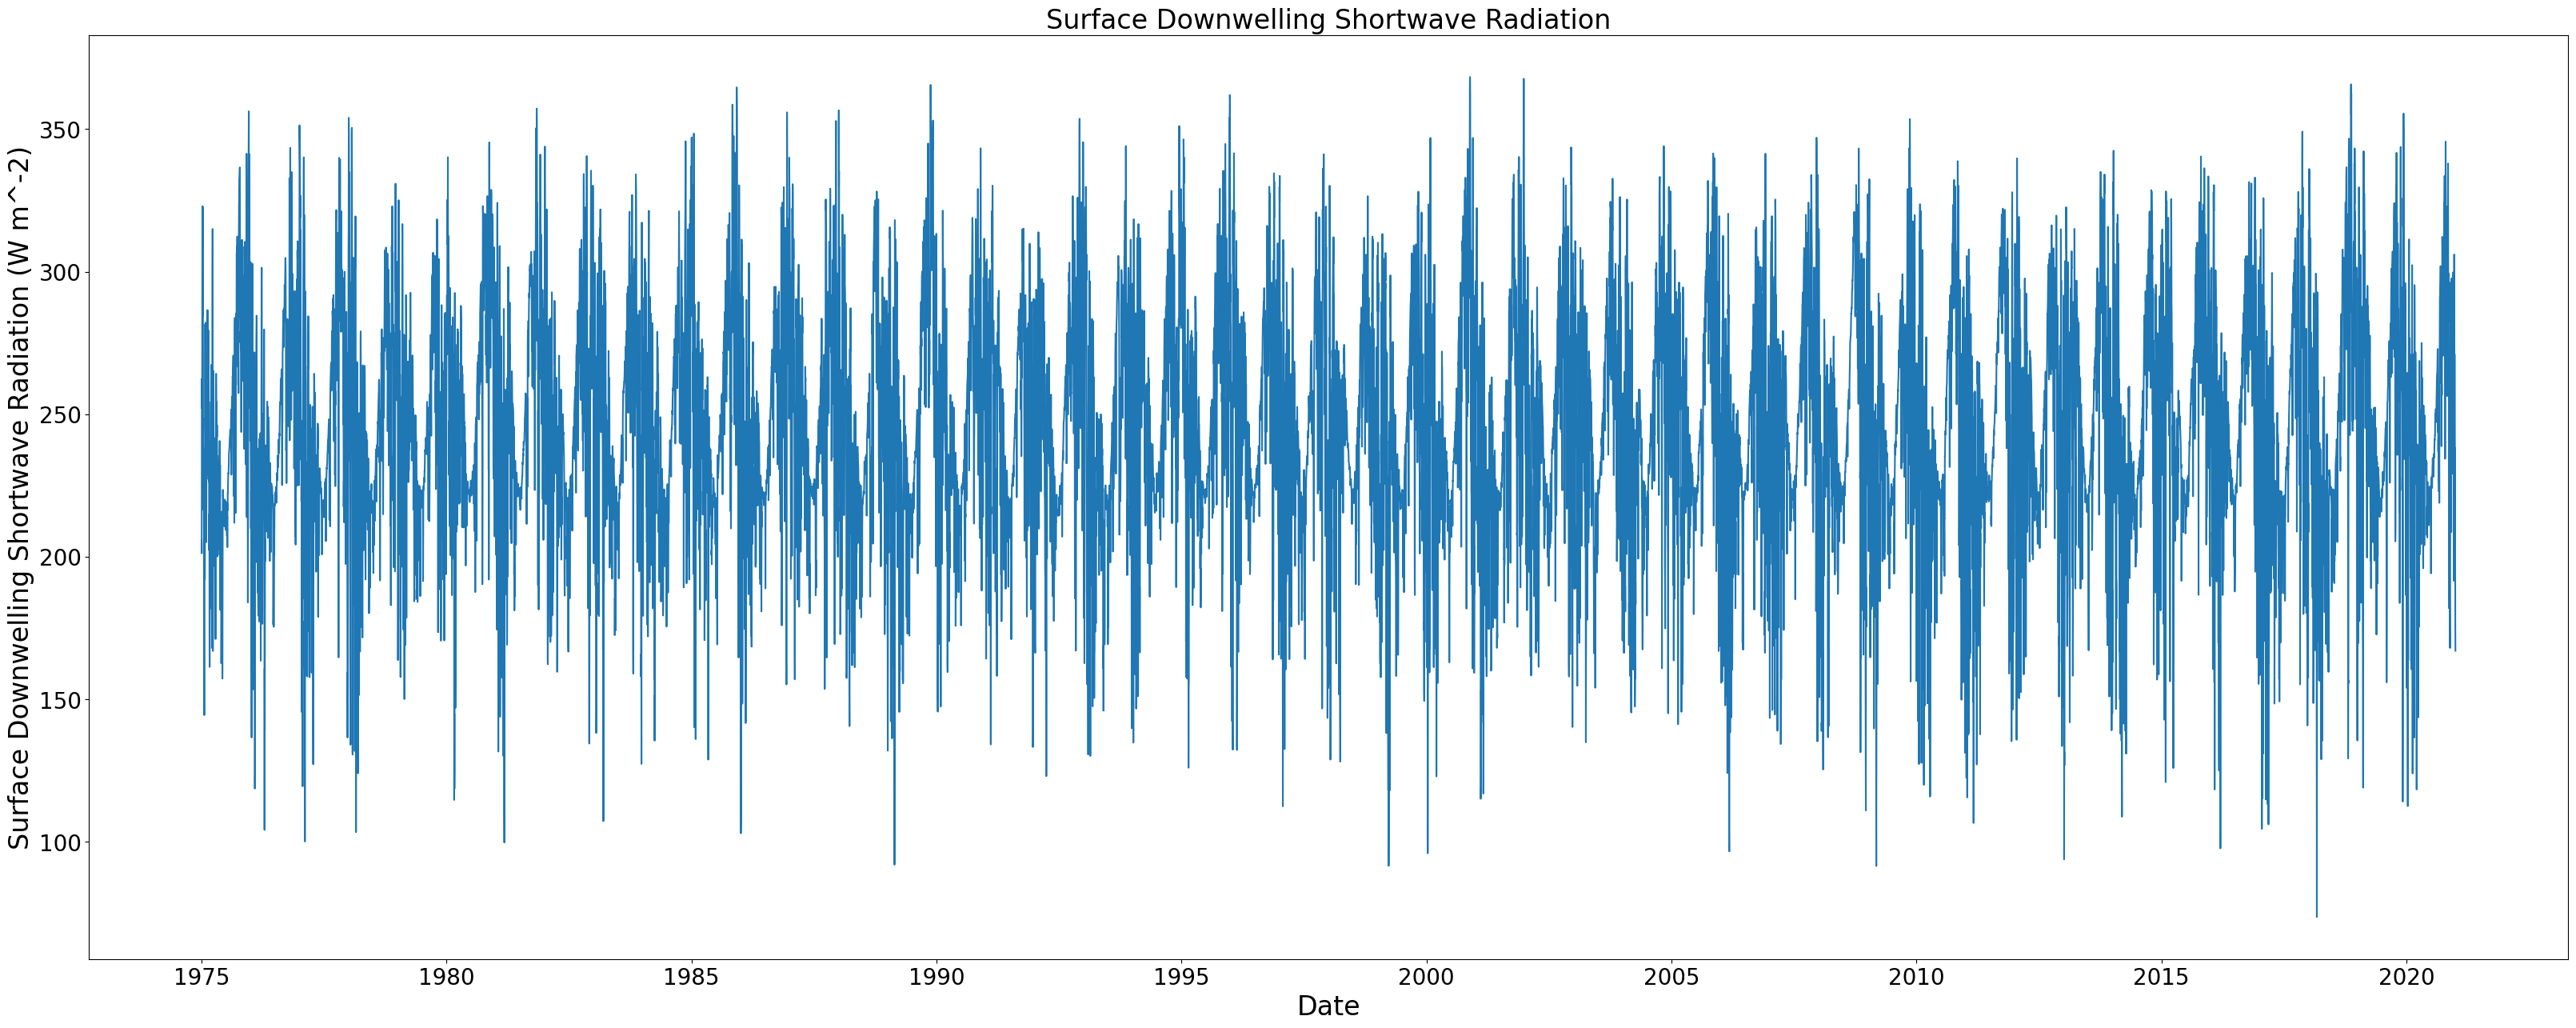

In [7]:
fig, ax = plt.subplots(figsize=(40, 15))
rsds['rsds'].plot(ax=ax)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Surface Downwelling Shortwave Radiation (W m^-2)", fontsize=24)
plt.title("Surface Downwelling Shortwave Radiation", fontsize=24);

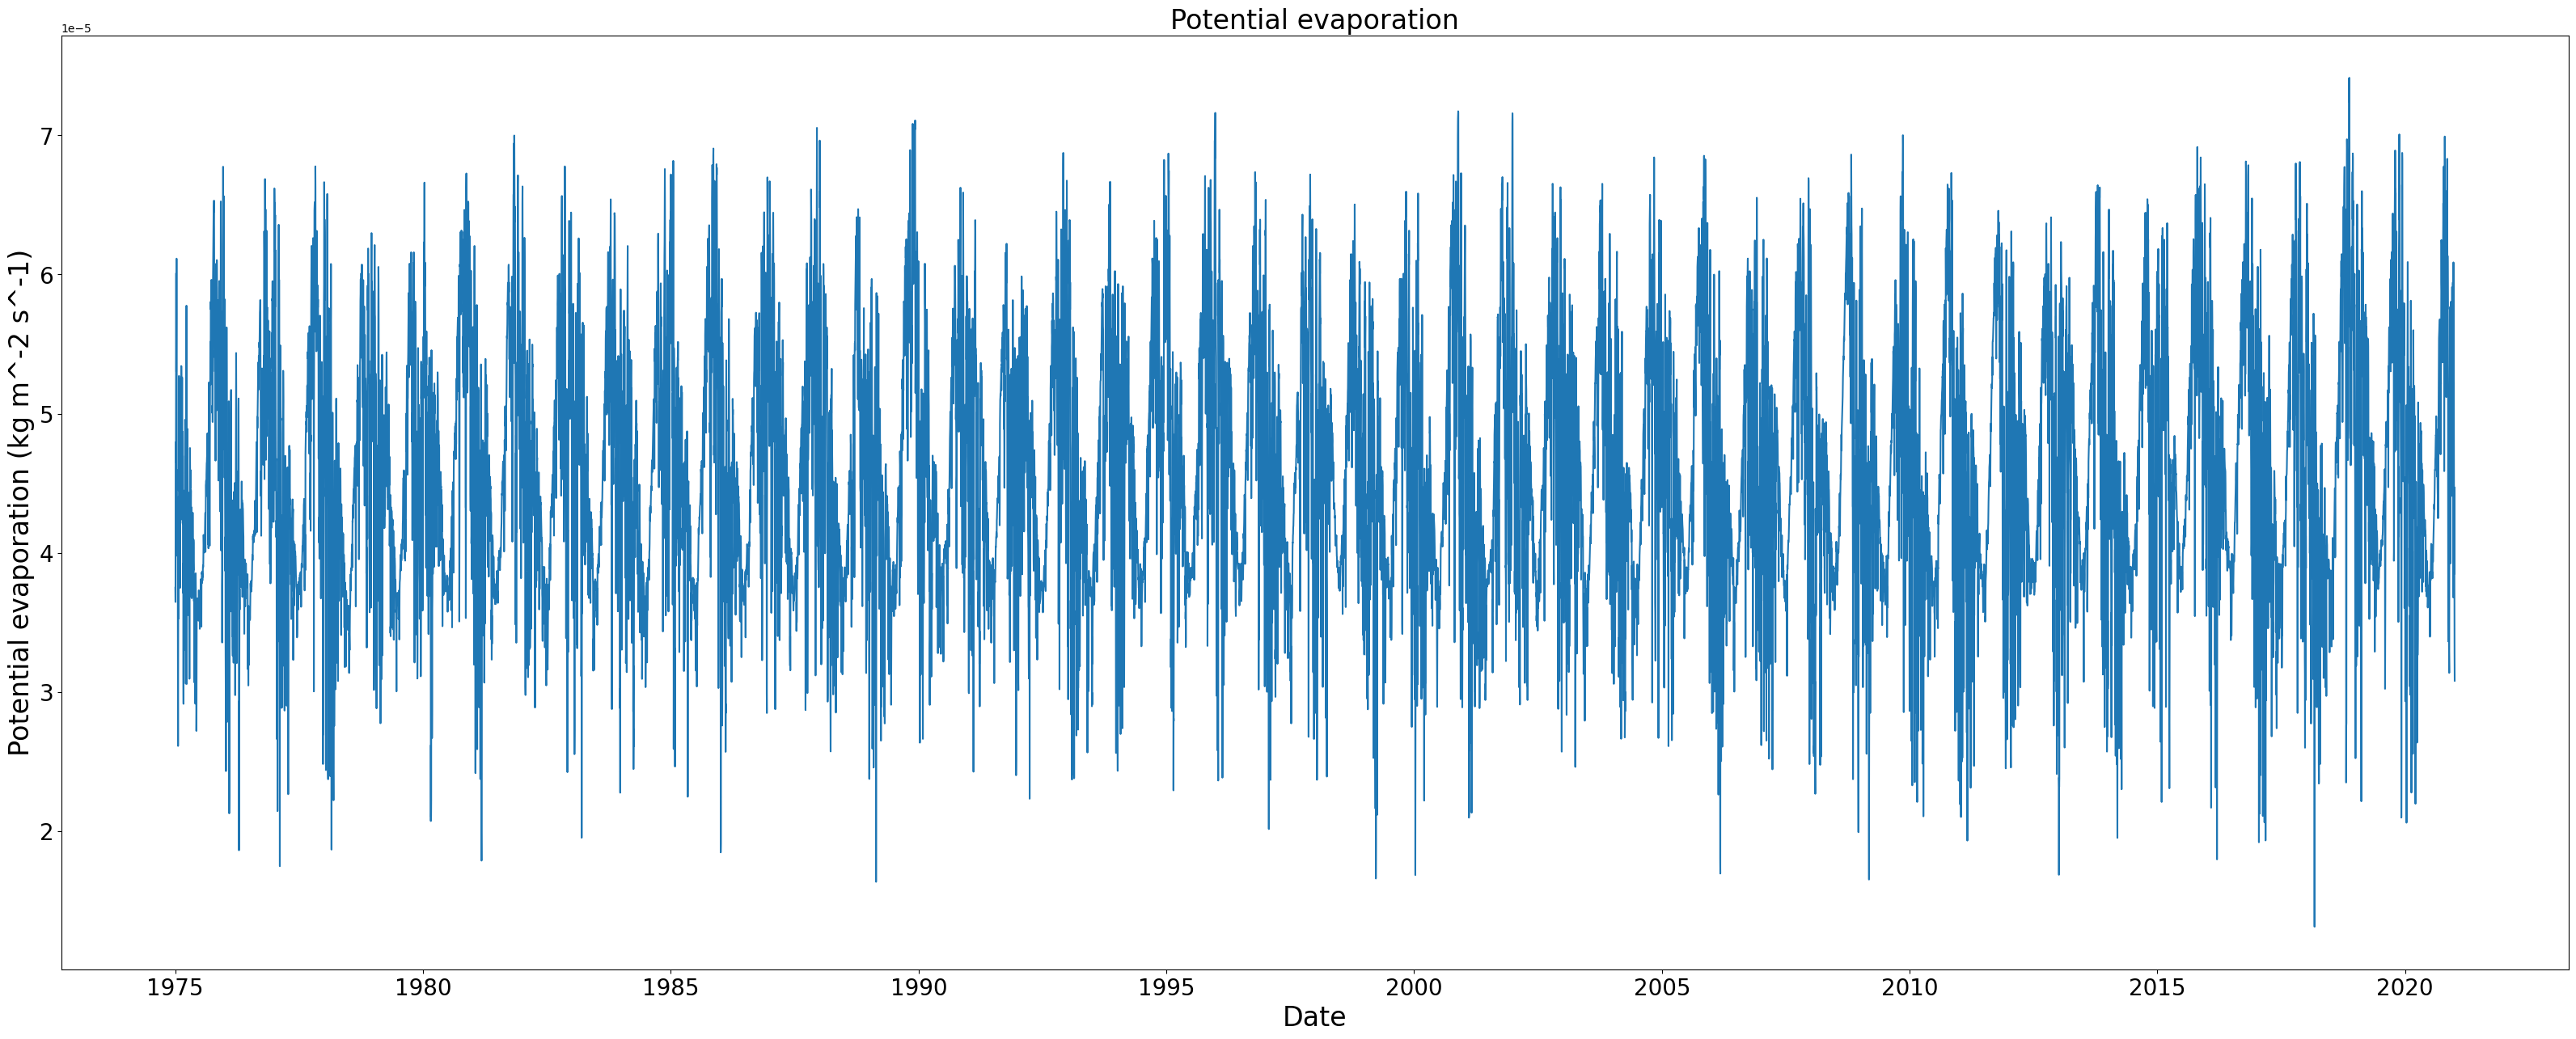

In [8]:
fig, ax = plt.subplots(figsize=(40, 15))
evspsblpot['evspsblpot'].plot(ax=ax)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Potential evaporation (kg m^-2 s^-1)", fontsize=24)
plt.title("Potential evaporation", fontsize=24);